# Multi-Class SVM Strategies: 2D Fisher Iris Data
Import libraries and data set.

In [34]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.multiclass import OutputCodeClassifier
from sklearn.inspection import DecisionBoundaryDisplay
import seaborn as sns
from sklearn.model_selection import train_test_split

# # View the data set as dataframe
# iris = load_iris(as_frame=True)
# print(iris.frame)

# # Get only the sepal length and petal length
# X, y = iris.data.to_numpy(), iris.target
# X = X[:,[0,2]]

# # Visualize 2D data
# plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
# plt.xlabel('Sepal Length (cm)')
# plt.ylabel('Petal Length (cm)')
# plt.show()

In [35]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "penguins_size.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "parulpandey/palmer-archipelago-antarctica-penguin-data",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df = df.dropna()

print(df.head())

C:\Users\pjtio\AppData\Local\Temp\ipykernel_7896\2915280823.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


  species     island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen              39.1             18.7              181.0   
1  Adelie  Torgersen              39.5             17.4              186.0   
2  Adelie  Torgersen              40.3             18.0              195.0   
4  Adelie  Torgersen              36.7             19.3              193.0   
5  Adelie  Torgersen              39.3             20.6              190.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
4       3450.0  FEMALE  
5       3650.0    MALE  


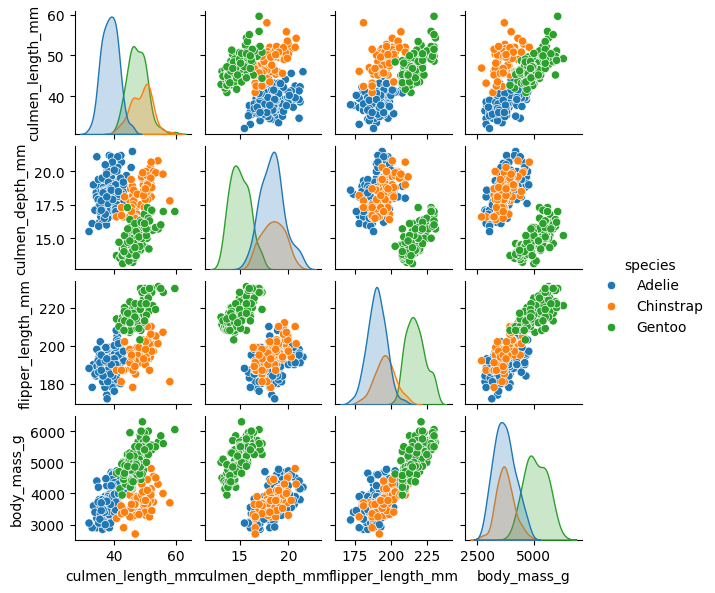

In [36]:
sns.pairplot(df, hue='species', height=1.5)
plt.show()

## Fit an SVM with ovr strategy

Training accuracy = 0.96
Training Confusion Matrix
[[106   1   2]
 [  4  45   2]
 [  0   1  89]]
Training Classification Report
              precision    recall  f1-score   support

      Adelie       0.96      0.97      0.97       109
   Chinstrap       0.96      0.88      0.92        51
      Gentoo       0.96      0.99      0.97        90

    accuracy                           0.96       250
   macro avg       0.96      0.95      0.95       250
weighted avg       0.96      0.96      0.96       250

Test accuracy = 0.9404761904761905
Test Confusion Matrix
[[35  2  0]
 [ 2 14  1]
 [ 0  0 30]]
Test Classification Report
              precision    recall  f1-score   support

      Adelie       0.95      0.95      0.95        37
   Chinstrap       0.88      0.82      0.85        17
      Gentoo       0.97      1.00      0.98        30

    accuracy                           0.94        84
   macro avg       0.93      0.92      0.93        84
weighted avg       0.94      0.94      0.94 

C:\Users\pjtio\AppData\Local\Temp\ipykernel_7896\2371968603.py:24: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test.map({'Adelie':0, 'Chinstrap':1, 'Gentoo':2}), marker='x', edgecolors="k")


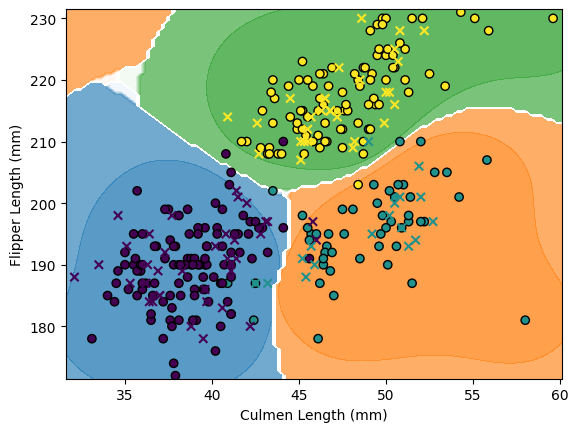

In [37]:
# Select features and target
X = df[['culmen_length_mm', 'flipper_length_mm']]
# X = df[['culmen_length_mm', 'flipper_length_mm']].dropna() # we can change the imputation strategy here
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

svm_ovo = OneVsOneClassifier(make_pipeline(StandardScaler(), SVC())).fit(X_train, y_train)

print(f"Training accuracy = {svm_ovo.score(X_train, y_train)}")
print('Training Confusion Matrix')
print(confusion_matrix(y_train, svm_ovo.predict(X_train)))
print('Training Classification Report')
print(classification_report(y_train, svm_ovo.predict(X_train)))

print(f"Test accuracy = {svm_ovo.score(X_test, y_test)}")
print('Test Confusion Matrix')
print(confusion_matrix(y_test, svm_ovo.predict(X_test)))
print('Test Classification Report')
print(classification_report(y_test, svm_ovo.predict(X_test)))

DecisionBoundaryDisplay.from_estimator(svm_ovo, X, alpha=0.8, eps=0.5)
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train.map({'Adelie':0, 'Chinstrap':1, 'Gentoo':2}), marker='o', edgecolors="k")
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test.map({'Adelie':0, 'Chinstrap':1, 'Gentoo':2}), marker='x', edgecolors="k")
plt.xlabel('Culmen Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.show()

## Fit an SVM with OvR strategy

Training accuracy = 0.96
Training Confusion Matrix
[[106   1   2]
 [  4  45   2]
 [  0   1  89]]
Training Classification Report
              precision    recall  f1-score   support

      Adelie       0.96      0.97      0.97       109
   Chinstrap       0.96      0.88      0.92        51
      Gentoo       0.96      0.99      0.97        90

    accuracy                           0.96       250
   macro avg       0.96      0.95      0.95       250
weighted avg       0.96      0.96      0.96       250

Test accuracy = 0.9404761904761905
Test Confusion Matrix
[[35  2  0]
 [ 2 14  1]
 [ 0  0 30]]
Test Classification Report
              precision    recall  f1-score   support

      Adelie       0.95      0.95      0.95        37
   Chinstrap       0.88      0.82      0.85        17
      Gentoo       0.97      1.00      0.98        30

    accuracy                           0.94        84
   macro avg       0.93      0.92      0.93        84
weighted avg       0.94      0.94      0.94 

C:\Users\pjtio\AppData\Local\Temp\ipykernel_7896\2676989708.py:17: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test.map({'Adelie':0, 'Chinstrap':1, 'Gentoo':2}), marker='x', edgecolors="k")


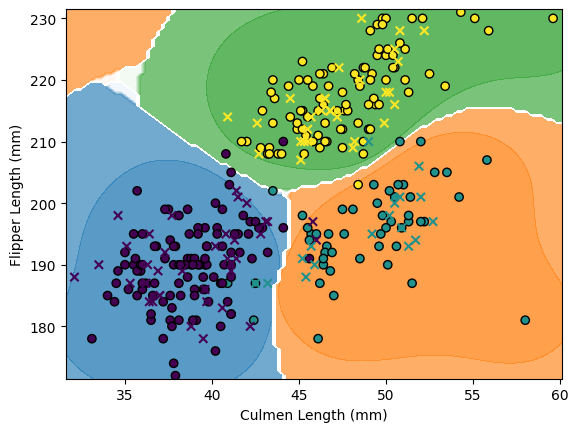

In [38]:
svm_ovr = OneVsRestClassifier(make_pipeline(StandardScaler(), SVC())).fit(X_train, y_train)

print(f"Training accuracy = {svm_ovr.score(X_train, y_train)}")
print('Training Confusion Matrix')
print(confusion_matrix(y_train, svm_ovr.predict(X_train)))
print('Training Classification Report')
print(classification_report(y_train, svm_ovr.predict(X_train)))

print(f"Test accuracy = {svm_ovr.score(X_test, y_test)}")
print('Test Confusion Matrix')
print(confusion_matrix(y_test, svm_ovr.predict(X_test)))
print('Test Classification Report')
print(classification_report(y_test, svm_ovr.predict(X_test)))

DecisionBoundaryDisplay.from_estimator(svm_ovo, X, alpha=0.8, eps=0.5)
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train.map({'Adelie':0, 'Chinstrap':1, 'Gentoo':2}), marker='o', edgecolors="k")
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test.map({'Adelie':0, 'Chinstrap':1, 'Gentoo':2}), marker='x', edgecolors="k")
plt.xlabel('Culmen Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.show()

## Fit an SVM with ECOC strategy

Training accuracy = 0.96
Training Confusion Matrix
[[106   1   2]
 [  4  45   2]
 [  0   1  89]]
Training Classification Report
              precision    recall  f1-score   support

      Adelie       0.96      0.97      0.97       109
   Chinstrap       0.96      0.88      0.92        51
      Gentoo       0.96      0.99      0.97        90

    accuracy                           0.96       250
   macro avg       0.96      0.95      0.95       250
weighted avg       0.96      0.96      0.96       250

Test accuracy = 0.9404761904761905
Test Confusion Matrix
[[35  2  0]
 [ 2 14  1]
 [ 0  0 30]]
Test Classification Report
              precision    recall  f1-score   support

      Adelie       0.95      0.95      0.95        37
   Chinstrap       0.88      0.82      0.85        17
      Gentoo       0.97      1.00      0.98        30

    accuracy                           0.94        84
   macro avg       0.93      0.92      0.93        84
weighted avg       0.94      0.94      0.94 

C:\Users\pjtio\AppData\Local\Temp\ipykernel_7896\259828232.py:21: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test.map({'Adelie':0, 'Chinstrap':1, 'Gentoo':2}), marker='x', edgecolors="k")


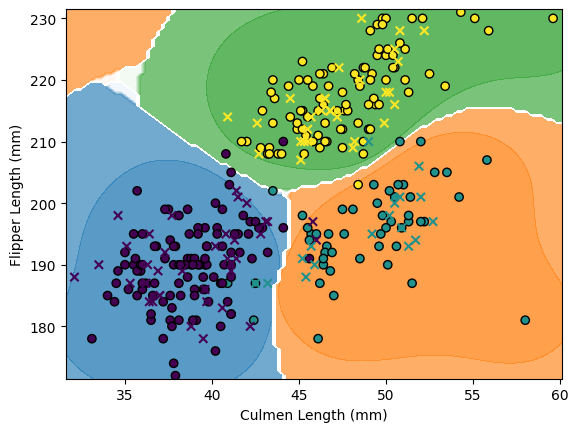

In [39]:
# Code_size is the percentage of n_classes to be used as length of codeword.
# Here, we have code_size=3, hence the codewords have length 3*3 = 9.
# This means that 9 binary classifiers will be trained.

svm_ecoc = OutputCodeClassifier(make_pipeline(StandardScaler(), SVC()),
                                code_size=3).fit(X,y)
print(f"Training accuracy = {svm_ecoc.score(X_train, y_train)}")
print('Training Confusion Matrix')
print(confusion_matrix(y_train, svm_ecoc.predict(X_train)))
print('Training Classification Report')
print(classification_report(y_train, svm_ecoc.predict(X_train)))

print(f"Test accuracy = {svm_ecoc.score(X_test, y_test)}")
print('Test Confusion Matrix')
print(confusion_matrix(y_test, svm_ecoc.predict(X_test)))
print('Test Classification Report')
print(classification_report(y_test, svm_ecoc.predict(X_test)))

DecisionBoundaryDisplay.from_estimator(svm_ovo, X, alpha=0.8, eps=0.5)
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train.map({'Adelie':0, 'Chinstrap':1, 'Gentoo':2}), marker='o', edgecolors="k")
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test.map({'Adelie':0, 'Chinstrap':1, 'Gentoo':2}), marker='x', edgecolors="k")
plt.xlabel('Culmen Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.show()